# Host or device? Let the data decide

> Debug one sample on the CPU, then run a whole batch on the GPU -- the
> same call, the same compiled kernel, no flag of your own to flip.

**Time:** ~3 min · **Runs on:** CPU (GPU: this notebook picks it up
automatically) · **You need:** {doc}`../quickstart_python`

You will build the figure below: the host run plotted against whichever run
the switch below picked, sample by sample.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent.parent / "_shared"))
from nb_helpers import gpu_available, to_numpy, xp_for


In [2]:
import numpy as np

DEVICE = "gpu" if gpu_available() else "cpu"
xp = xp_for(DEVICE)
print("running on", DEVICE)

running on cpu


## The code: one call, the data decides

{func}`eagle.deploy` builds an {class}`~eagle.plan.AutoPlan`: every call to
`.run()`/`.select()` looks at the *planes you hand it*, never the sample
count, to pick where the kernel runs. A cupy-resident plane sends the whole
call through `eagle.exec.DeviceKernel`; a Python number, a 0-d array, or a
numpy array runs it through `eagle.exec.HostTeam` instead -- the same
compiled kernel either way.

In [3]:
import eagle
import eagle.exec as eexec
import hawk
from hawk import Mutable, Param, Scalar


@hawk.kernel
def scale(x: Scalar, a: Param, b: Param, y: Mutable[Scalar]):
    y = a * x + b


def structure_of(plan, planes):
    s = plan.select(planes).structure
    return "HostTeam (CPU)" if s is eexec.HostTeam else "DeviceKernel (GPU)"


plan = eagle.deploy(scale)

# One sample, debugged with plain floats: no GPU, no batch, no cupy import.
one = plan.run(x=0.5, a=2.0, b=-1.0)
print(f"one sample: {type(one).__name__} {float(one)} (shape {one.shape}) "
      f"-- ran on {structure_of(plan, dict(x=0.5, a=2.0, b=-1.0))}")

one sample: float64 0.0 (shape ()) -- ran on HostTeam (CPU)


## A batch: still one call

Nothing above changes for a batch of thousands: `x` becomes an array instead
of a float, and the *same* `plan.run` sends it wherever that array already
lives. Below, `y_host` is forced through numpy (always the CPU); `y_xp` goes
through whichever array type the switch above picked -- numpy on this run if
no GPU is visible, cupy if one is.

In [4]:
n = 2000
rng = np.random.default_rng(7)
x_np = rng.uniform(-5.0, 5.0, n)

y_host = plan.run(x=x_np, a=1.7, b=-0.4)
y_xp = plan.run(x=xp.asarray(x_np), a=1.7, b=-0.4)

print("host run:", structure_of(plan, dict(x=x_np, a=1.7, b=-0.4)))
print("xp run:  ", structure_of(plan, dict(x=xp.asarray(x_np), a=1.7, b=-0.4)))
print("agree:", bool(np.allclose(y_host, to_numpy(y_xp))))

host run: HostTeam (CPU)
xp run:   HostTeam (CPU)
agree: True


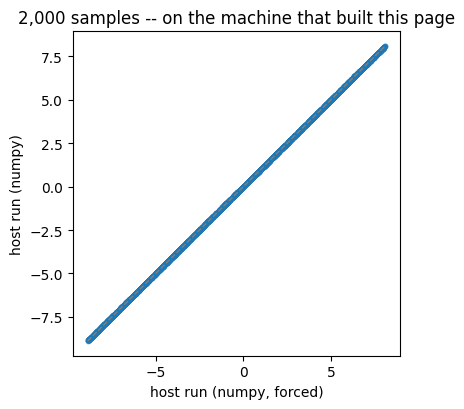

In [5]:
import matplotlib.pyplot as plt

y_xp_home = to_numpy(y_xp)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(y_host, y_xp_home, s=10, c="C0", alpha=0.6)
lo = float(min(y_host.min(), y_xp_home.min()))
hi = float(max(y_host.max(), y_xp_home.max()))
ax.plot([lo, hi], [lo, hi], "--", color="gray", lw=1)
ax.set_xlabel("host run (numpy, forced)")
label = "device" if DEVICE == "gpu" else "host"
array_lib = "cupy" if DEVICE == "gpu" else "numpy"
ax.set_ylabel(f"{label} run ({array_lib})")
ax.set_title(f"{n:,} samples -- on the machine that built this page")
fig.tight_layout()
plt.show()

## What just happened

- `eagle.deploy` returned one `AutoPlan` for `scale`; every `.run()` call
  looked only at the planes it was given -- a float, or which array type `x`
  arrived as -- to pick `eagle.exec.HostTeam` or `eagle.exec.DeviceKernel`.
- A Python float is a batch of one, always on the host: the same call that
  drives a two-thousand-sample batch above also debugged a single value,
  with no separate code path and no GPU required.
- `y_host` and `y_xp` sit on the diagonal above: the forced-host run and
  whichever run the switch picked agree on every sample (to the last bit, or
  within the one ULP a fused multiply-add on the device may contribute).

## When the CPU wins

Picking a side is not always "the GPU wins": on eagle's adaptive RK7(8)
workload (the family's other performance card), the CPU-only arm beats every
GPU arm at the largest batch size measured -- an adaptive, branch-heavy
per-sample step leaves little for the GPU's wider lanes to amortize against
their own launch overhead. The same mechanism above is what lets a kernel
move to the faster side with no code change once you know which one it is;
deeper: {doc}`../../performance` ("GPU vs. CPU").

## Try this

Widen the batch to 2,000,000 samples and compare `structure_of`'s answer on
a machine with a GPU visible against one without -- the call is unchanged
either way.

## Next

- {doc}`../../interop` -- the same "host or device" idea, generalized to
  every array framework eagle recognizes (numpy, cupy, torch, Warp).
- deeper: {doc}`../../performance` -- the full measurement behind the "when
  the CPU wins" box above.